# 04. Causal Models

**Input**: `accepted_modeling.parquet` produced by Notebook 02

**Research question**: Among observationally similar approved Lending Club borrowers, how much does a higher interest rate within the same grade increase the probability of default?

**Treatment**: `high_rate` — above-median interest rate within the same grade  
**Outcome**: `default` (binary)  
**Identification assumption**: Conditional on observable borrower characteristics, within-grade rate assignment is as-good-as-random.

**Methods**:
1. **Propensity Score Weighting (IPW)**
2. **Doubly Robust Estimation (AIPW)**
3. **Double Machine Learning (DML)** — continuous treatment
4. **Causal Forest** — heterogeneous treatment effects (CATE)
5. **Sub-grade Boundary Analysis** — local Wald estimates

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.base import clone

from scipy import stats
from scipy.stats import norm
from econml.dml import CausalForestDML

sns.set_theme(style='whitegrid', font_scale=1.1)
os.chdir("C:/Users/David Cho/OneDrive/Desktop/Projects/credit-risk-causal-analysis")

In [4]:
OUTPUT_DIR  = './outputs/intermediate'
FIGURE_DIR = './outputs/figures'

GRADE_ORDER   = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
GRADE_PALETTE = sns.color_palette('RdYlGn_r', n_colors=7)

mdf = pd.read_parquet(f'{OUTPUT_DIR}/accepted_modeling.parquet')
with open(f'{OUTPUT_DIR}/meta.json') as f:
    meta = json.load(f)
COVARIATES = [c for c in meta['COVARIATES'] if c in mdf.columns]

print(f'Modeling dataset : {mdf.shape}')
print(f'Default rate     : {mdf["default"].mean():.4f}')
print(f'Treated fraction : {mdf["high_rate"].mean():.4f}')
print(f'Covariates       : {len(COVARIATES)}')

Modeling dataset : (1025917, 29)
Default rate     : 0.2009
Treated fraction : 0.4694
Covariates       : 24


In [6]:
y = mdf['default'].values
T_bin = mdf['high_rate'].values
T_cont = mdf['int_rate'].values
COVARIATES2 = [col for col in COVARIATES if col != 'subgrade_num']
X = mdf[COVARIATES2].fillna(0).astype(float).values

---
## Method 1 — Propensity Score Weighting (IPW)

Propensity score weighting was implemented to address strong risk-based treatment assignment, as borrowers receiving higher interest rates differed substantially from those receiving lower rates in observable risk characteristics. By reweighting observations based on the estimated probability of receiving high pricing, we constructed a pseudo-population in which treated and control borrowers became more comparable. This substantially reduced covariate imbalance, improved overlap, and enabled more credible estimation of the causal effect of higher intrest rate within grades on default.

In [8]:
# Estimate propensity scores via 5-fold cross-fitting to avoid in-sample overfitting.
ps_pipe = Pipeline([
    ('lr', LogisticRegression(C=0.5, max_iter=500))
])
cv_ps  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ps_hat = cross_val_predict(ps_pipe, X, T_bin, cv=cv_ps, method='predict_proba')[:, 1]

print(f'PS range : [{ps_hat.min():.4f}, {ps_hat.max():.4f}]')
print(f'PS AUC   : {roc_auc_score(T_bin, ps_hat):.4f}')

PS range : [0.0005, 0.8873]
PS AUC   : 0.6468


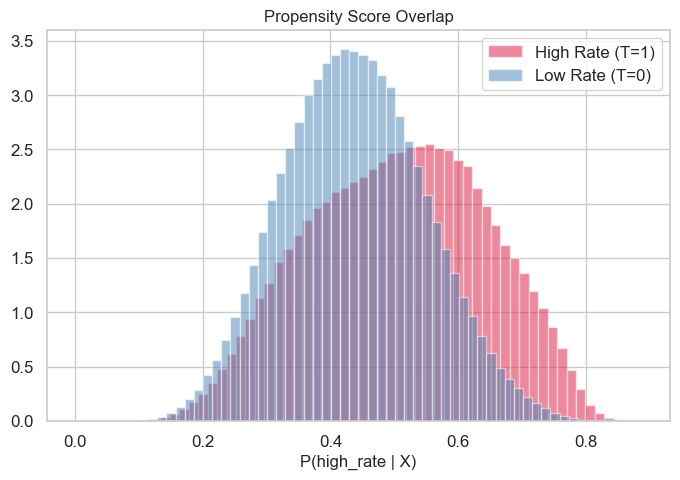

In common support: 1,025,905 (100.0%)


In [68]:
# Overlap check
ps_t = ps_hat[T_bin == 1]
ps_c = ps_hat[T_bin == 0]

lower = max(ps_t.min(), ps_c.min())
upper = min(ps_t.max(), ps_c.max())

in_support = (ps_hat >= lower) & (ps_hat <= upper)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

mask = np.ones(len(ps_hat), dtype=bool)

for t, color, lbl in [
    (1, 'crimson', 'High Rate (T=1)'),
    (0, 'steelblue', 'Low Rate (T=0)')
]:
    m = mask & (T_bin == t)
    ax.hist(ps_hat[m], bins=60, alpha=0.5, color=color, density=True, label=lbl)

ax.set_xlabel('P(high_rate | X)', fontsize=12)
ax.set_title(f'Propensity Score Overlap', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig17_ps_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'In common support: {in_support.sum():,} ({in_support.mean():.1%})')

The propensity score distributions for high-rate and low-rate borrowers show substantial overlap across a wide range of values, indicating that treatment assignment is not nearly deterministic given observable characteristics. Both groups are well represented throughout the common support region, suggesting that treated borrowers can be meaningfully compared with observationally similar controls. This strong overlap improves the credibility of causal effect estimation by reducing reliance on extrapolation and supporting the positivity assumption.

### Stabilized Hájek estimator (Stabilization + Normalization)

In [88]:
# Clip propensity score as extreme values can cause variance explosion.
ps_hat_clip = np.clip(ps_hat, np.percentile(ps_hat, 1), np.percentile(ps_hat, 99))

print(f'*After clip {np.percentile(ps_hat, 1):.2f}-{np.percentile(ps_hat, 99):.2f}:')
print(f'   PS range : [{ps_hat_clip.min():.2f}, {ps_hat_clip.max():.2f}]')
print(f'   PS AUC   : {roc_auc_score(T_bin, ps_hat_clip):.2f}')
print()
print('Still max is above 0.5. Stabilized Weights will be used when calculating IPW.')

*After clip 0.20-0.76:
   PS range : [0.20, 0.76]
   PS AUC   : 0.65

Still max is above 0.5. Stabilized Weights will be used when calculating IPW.


In [99]:
# Propensity Score Weighting
p_t = T_bin.mean()
p_c = 1 - p_t

# ATE: stabilized + normalized (Hájek)
w_ate_stab = np.where(
    T_bin == 1,
    p_t / ps_hat_clip,
    p_c / (1 - ps_hat_clip)
)

mu1 = np.sum((T_bin == 1) * w_ate_stab * y) / np.sum((T_bin == 1) * w_ate_stab)
mu0 = np.sum((T_bin == 0) * w_ate_stab * y) / np.sum((T_bin == 0) * w_ate_stab)
ate_ipw = mu1 - mu0

# ATT: normalized
w_att = np.where(
    T_bin == 1,
    1.0,
    ps_hat_clip / (1 - ps_hat_clip)
)

att_treated = np.sum((T_bin == 1) * y) / np.sum(T_bin == 1)
att_control = np.sum((T_bin == 0) * w_att * y) / np.sum((T_bin == 0) * w_att)
att_ipw = att_treated - att_control


# Bootstrap 95% CI for ATE
np.random.seed(42)
n = len(y)
boot = []

for _ in range(500):
    idx = np.random.choice(n, size=n, replace=True)

    y_b = y[idx]
    T_b = T_bin[idx]
    ps_b = np.clip(ps_hat_clip[idx], 0.01, 0.99)

    p_t_b = T_b.mean()
    p_c_b = 1 - p_t_b

    w_b = np.where(
        T_b == 1,
        p_t_b / ps_b,
        p_c_b / (1 - ps_b)
    )

    denom1 = np.sum((T_b == 1) * w_b)
    denom0 = np.sum((T_b == 0) * w_b)

    if denom1 == 0 or denom0 == 0:
        continue

    mu1_b = np.sum((T_b == 1) * w_b * y_b) / denom1
    mu0_b = np.sum((T_b == 0) * w_b * y_b) / denom0

    boot.append(mu1_b - mu0_b)

boot = np.array(boot)
ci_lo_ipw, ci_hi_ipw = np.percentile(boot, [2.5, 97.5])

print("=== PROPENSITY SCORE WEIGHTING ===")
print(f"Naive difference : {ate_naive*100:+.4f} pp")
print(f"IPW-ATE          : {ate_ipw*100:+.4f} pp   95% CI [{ci_lo_ipw*100:.3f}, {ci_hi_ipw*100:.3f}]")
print(f"IPW-ATT          : {att_ipw*100:+.4f} pp")

=== PROPENSITY SCORE WEIGHTING ===
Naive difference : +1.7073 pp
IPW-ATE          : +2.4473 pp   95% CI [2.281, 2.615]
IPW-ATT          : +0.9162 pp


The propensity score–weighted estimates indicate that higher loan pricing increases default risk. While the naive comparison suggests a 1.7 percentage point higher default rate among high-rate borrowers, the IPW-ATE rises to approximately 2.4 percentage points after adjusting for observable borrower characteristics. This increase suggests that risk sorting was partially masking the true repayment burden effect of higher interest rates in the unadjusted comparison. The IPW-ATT estimate, although still positive, is smaller than the IPW-ATE, indicating that borrowers who actually received higher pricing are on average more risk-tolerant or less sensitive to pricing changes than the broader population. This pattern is consistent with treatment effect heterogeneity, where pricing increases default risk overall but has a relatively weaker marginal impact within the subset of borrowers most likely to face higher rates.

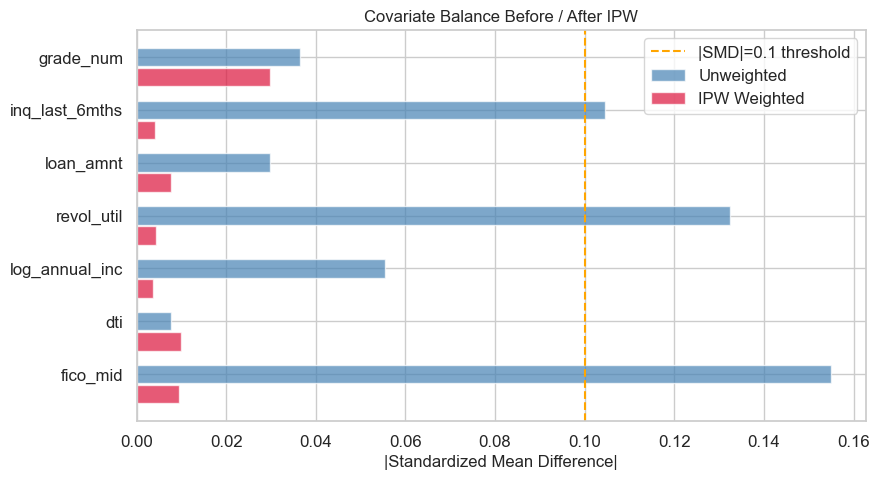

      Variable  SMD_Unweighted  SMD_IPW
      fico_mid          0.1550   0.0094
           dti          0.0078   0.0098
log_annual_inc          0.0555   0.0037
    revol_util          0.1324   0.0044
     loan_amnt          0.0298   0.0078
inq_last_6mths          0.1045   0.0042
     grade_num          0.0365   0.0297


In [102]:
# Covariate balance before and after IPW
BALANCE_VARS = ['fico_mid', 'dti', 'log_annual_inc', 'revol_util',
                'loan_amnt', 'inq_last_6mths', 'grade_num', 'term_months']
BALANCE_VARS = [v for v in BALANCE_VARS if v in mdf.columns]

def weighted_var(x, w):
    avg = np.average(x, weights=w)
    return np.average((x - avg)**2, weights=w)

balance_rows = []
for var in BALANCE_VARS:
    vals = mdf[var].values
    sd_uw = np.sqrt((vals[T_bin==1].std()**2 + vals[T_bin==0].std()**2) / 2)
    smd_uw = (vals[T_bin==1].mean() - vals[T_bin==0].mean()) / (sd_uw + 1e-9)
    
    m1_w = np.average(vals[T_bin==1], weights=w_ate_stab[T_bin==1])
    m0_w = np.average(vals[T_bin==0], weights=w_ate_stab[T_bin==0])
    var_T = weighted_var(vals[T_bin==1], w_ate_stab[T_bin==1])
    var_C = weighted_var(vals[T_bin==0], w_ate_stab[T_bin==0])
    sd_w = np.sqrt((var_T + var_C) / 2)
    smd_w  = (m1_w - m0_w) / (sd_w + 1e-9)
    balance_rows.append({'Variable': var, 'SMD_Unweighted': abs(smd_uw), 'SMD_IPW': abs(smd_w)})

bal_df = pd.DataFrame(balance_rows)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bal_df))
ax.barh(bal_df['Variable'], np.abs(bal_df['SMD_Unweighted']),
        height=0.35, label='Unweighted', color='steelblue', alpha=0.7)
ax.barh(x - 0.38, np.abs(bal_df['SMD_IPW']),
        height=0.35, label='IPW Weighted', color='crimson', alpha=0.7)
ax.axvline(0.1, color='orange', linestyle='--', linewidth=1.5, label='|SMD|=0.1 threshold')
ax.set_xlabel('|Standardized Mean Difference|', fontsize=12)
ax.set_title('Covariate Balance Before / After IPW', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig18_ipw_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(bal_df.round(4).to_string(index=False))

Propensity score weighting substantially improves covariate balance between high-rate and low-rate borrowers, reducing all standardized mean differences below conventional thresholds. This indicates that the weighted sample achieves strong comparability in observable risk characteristics, supporting more credible estimation of the causal impact of loan pricing on default.

---
## Method 2 — Doubly Robust Estimation (AIPW)

Doubly Robust estimation (or Augmented IPW) combines two approaches to causal inference:
 1) modeling the outcome as a function of covariates given treatment status, and
 2) modeling the treatment assignment via the propensity score.

Augmented IPW combines two models: a propensity score model for treatment assignment and outcome models for the treated and controlled potential outcomes. The estimator is doubly robust, meaning it remains consistent if either the propensity score model or the outcome model is correctly specified. Cross-fitting further reduces overfitting bias by ensuring that predictions are generated out of sample.

In [108]:
cv_dr  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ps_cf  = np.zeros(len(y))
mu1_cf = np.zeros(len(y))
mu0_cf = np.zeros(len(y))

ps_dr = LogisticRegression(C=0.5, max_iter=500)

xgb_outcome = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

for fold, (tr, te) in enumerate(cv_dr.split(X, T_bin)):
    ps_dr.fit(X[tr], T_bin[tr])
    ps_cf[te] = ps_dr.predict_proba(X[te])[:, 1]

    m1 = clone(xgb_outcome); m1.fit(X[tr][T_bin[tr]==1], y[tr][T_bin[tr]==1])
    m0 = clone(xgb_outcome); m0.fit(X[tr][T_bin[tr]==0], y[tr][T_bin[tr]==0])
    mu1_cf[te] = m1.predict_proba(X[te])[:, 1]
    mu0_cf[te] = m0.predict_proba(X[te])[:, 1]

    print(f'  Fold {fold+1}/5  PS AUC={roc_auc_score(T_bin[te], ps_cf[te]):.4f}')

ps_cf_c = np.clip(ps_cf, 0.01, 0.99)

psi = (
    (mu1_cf - mu0_cf)
    + T_bin * (y - mu1_cf) / ps_cf_c
    - (1 - T_bin) * (y - mu0_cf) / (1 - ps_cf_c)
)

dr_att_score = (
    T_bin * (y - mu0_cf)
    - (1 - T_bin) * (ps_cf_c / (1 - ps_cf_c)) * (y - mu0_cf)
)

ate_aipw = psi.mean()
att_aipw = dr_att_score.sum()/T_bin.sum()   
se_aipw = psi.std() / np.sqrt(len(psi))
ci_lo_aipw = ate_aipw - 1.96 * se_aipw
ci_hi_aipw = ate_aipw + 1.96 * se_aipw
z_aipw = ate_aipw / se_aipw
p_aipw = 2 * (1 - norm.cdf(abs(z_aipw)))

print()
print('=== AIPW (DOUBLY ROBUST) ===')
print(f'AIPW - ATE  : {ate_aipw*100:+.4f} pp')
print(f'AIPW - ATT  : {att_aipw*100:+.4f} pp')
print(f'SE          : {se_aipw*100:.4f} pp')
print(f'95% CI      : [{ci_lo_aipw*100:.4f}, {ci_hi_aipw*100:.4f}] pp')
print(f'z           : {z_aipw:.3f}   p = {p_aipw:.4f}')

  Fold 1/5  PS AUC=0.6464
  Fold 2/5  PS AUC=0.6471
  Fold 3/5  PS AUC=0.6459
  Fold 4/5  PS AUC=0.6470
  Fold 5/5  PS AUC=0.6479

=== AIPW (DOUBLY ROBUST) ===
AIPW - ATE  : +2.0800 pp
AIPW - ATT  : +2.0353 pp
SE          : 0.0808 pp
95% CI      : [1.9218, 2.2383] pp
z           : 25.758   p = 0.0000


The doubly robust estimates indicate a statistically significant and economically meaningful positive effect of higher interest rates on default risk, with both ATE and ATT around 2 percentage points. The similarity between ATE and ATT suggests limited treatment effect heterogeneity, indicating that the impact of higher interest rates on default risk is relatively uniform across the population.

---
## Method 3 — Double Machine Learning (DML)

**Partially linear model** (Robinson 1988; Chernozhukov et al. 2018):  
`Y = θ·T + g(X) + ε` ,  `T = m(X) + v`  
θ estimated by OLS on cross-fitted residuals.

For the DML specification, using the continuous interest rate as the treatment is preferable because the partially linear framework is designed to estimate a marginal pricing effect. The binary high-rate indicator is better suited for overlap-based designs such as IPW or AIPW, where it provides a more interpretable local treatment contrast within risk groups.

In [111]:
cv_dml   = KFold(n_splits=5, shuffle=True, random_state=42)
y_resid  = np.zeros(len(y))
T_resid  = np.zeros(len(y))

m_Y = XGBClassifier(
    n_estimators=200, 
    max_depth=4, 
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

m_T = XGBRegressor(
    n_estimators=200, 
    max_depth=4, 
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

for fold, (tr, te) in enumerate(cv_dml.split(X)):
    m_Y.fit(X[tr], y[tr])      
    y_resid[te] = y[te] - m_Y.predict_proba(X[te])[:, 1]
    m_T.fit(X[tr], T_cont[tr]) 
    T_resid[te] = T_cont[te] - m_T.predict(X[te])
    print(f'  Fold {fold+1}/5  y_resid_std={y_resid[te].std():.4f}  T_resid_std={T_resid[te].std():.4f}')

theta_dml = (T_resid @ y_resid) / (T_resid @ T_resid)
eps       = y_resid - theta_dml * T_resid
se_dml    = np.sqrt(np.sum(T_resid**2 * eps**2) / (np.sum(T_resid**2))**2)

r2_first  = 1 - np.var(T_resid) / np.var(T_cont)

print()
print('=== DOUBLE MACHINE LEARNING ===')
print(f'θ̂  : {theta_dml*100:+.6f} pp per 1 pp rate increase')
print(f'SE : {se_dml*100:.6f} pp')
print(f'95% CI : [{(theta_dml-1.96*se_dml)*100:+.5f}, {(theta_dml+1.96*se_dml)*100:+.5f}] pp')
print(f'First-stage R² : {r2_first:.4f}')

  Fold 1/5  y_resid_std=0.3785  T_resid_std=1.0698
  Fold 2/5  y_resid_std=0.3781  T_resid_std=1.0692
  Fold 3/5  y_resid_std=0.3789  T_resid_std=1.0685
  Fold 4/5  y_resid_std=0.3781  T_resid_std=1.0657
  Fold 5/5  y_resid_std=0.3789  T_resid_std=1.0651

=== DOUBLE MACHINE LEARNING ===
θ̂  : +1.153222 pp per 1 pp rate increase
SE : 0.035839 pp
95% CI : [+1.08298, +1.22347] pp
First-stage R² : 0.9463


The DML estimator is obtained by regressing the residualized outcome on the residualized treatment, where both residuals are constructed using cross-fitted machine learning models. The coefficient corresponds to the slope of this orthogonalized relationship, and standard errors are computed using a heteroskedasticity-robust variance formula.

After flexibly controlling for borrower risk, a 1 percentage point increase in interest rate leads to an approximately 1.15 percentage point increase in default probability, with a precisely estimated and statistically significant effect.

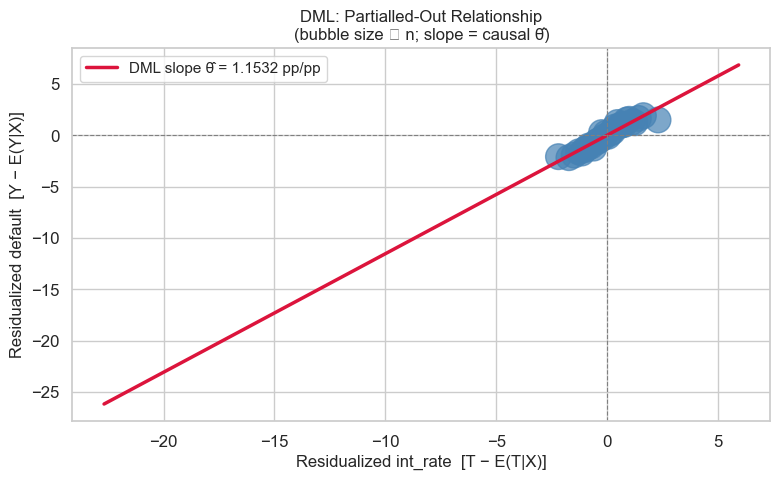

In [114]:
# Residual scatter: partialled-out T vs. partialled-out Y
T_bin_df = pd.DataFrame({'T_resid': T_resid, 'y_resid': y_resid})
T_bin_df['bin'] = pd.qcut(T_bin_df['T_resid'], q=30, duplicates='drop')
T_agg = T_bin_df.groupby('bin', observed=True).agg(
    T_mid=('T_resid','mean'), y_mean=('y_resid','mean'), n=('y_resid','count')
).reset_index()

x_line = np.linspace(T_resid.min(), T_resid.max(), 100)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(T_agg['T_mid'], T_agg['y_mean']*100,
           s=T_agg['n']/100, alpha=0.7, color='steelblue')
ax.plot(x_line, theta_dml * x_line * 100, color='crimson', linewidth=2.5,
        label=f'DML slope θ̂ = {theta_dml*100:.4f} pp/pp')
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Residualized int_rate  [T − E(T|X)]', fontsize=12)  
ax.set_ylabel('Residualized default  [Y − E(Y|X)]', fontsize=12)
ax.set_title('DML: Partialled-Out Relationship\n(bubble size ∝ n; slope = causal θ̂)', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig19_dml_residual.png', dpi=150, bbox_inches='tight')
plt.show()

The figure illustrates the partialled-out relationship between interest rate and default after removing the influence of observed covariates. The positive slope indicates that deviations in pricing beyond what is explained by borrower characteristics are associated with higher default risk, supporting a causal interpretation of the pricing effect.

---
## Method 4 — Causal Forest / CATE

Causal Forest is a machine learning method for estimating heterogeneous treatment effects using an extension of random forests. Unlike standard predictive models that focus on outcome prediction, causal forests are designed to estimate how the effect of a treatment varies across individuals with different characteristics.

The method builds an ensemble of decision trees that recursively partition the feature space to create subgroups of similar observations. Within each leaf, the model compares outcomes between treated and control units to estimate a local treatment effect. By averaging across many trees, causal forests produce stable and flexible estimates of treatment heterogeneity.

The causal forest is used to estimate the Conditional Average Treatment Effect (CATE) for each borrower, which represents the expected impact of receiving a high rate given their specific observed features. This allows us to understand how the effect of interest rates varies across different borrower segments rather than assuming a single average effect.

In [134]:
cf = CausalForestDML(
    model_y=GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    model_t=LogisticRegression(C=0.5, max_iter=500),
    n_estimators=500, 
    min_samples_leaf=50,
    discrete_treatment=True, 
    cv=5, 
    random_state=42
)

cf.fit(y.astype(float), T_bin, X=X)
cate = cf.effect(X)

ate_cf = cate.mean()
print(f'Overall Mean CATE: {ate_cf*100:+.4f} pp\n')
print(pd.Series(cate).describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).round(4))

Overall Mean CATE: +1.8027 pp

count    1.025917e+06
mean     1.800000e-02
std      1.030000e-02
min     -3.550000e-02
10%      4.900000e-03
25%      1.170000e-02
50%      1.830000e-02
75%      2.480000e-02
90%      3.080000e-02
max      6.600000e-02
dtype: float64


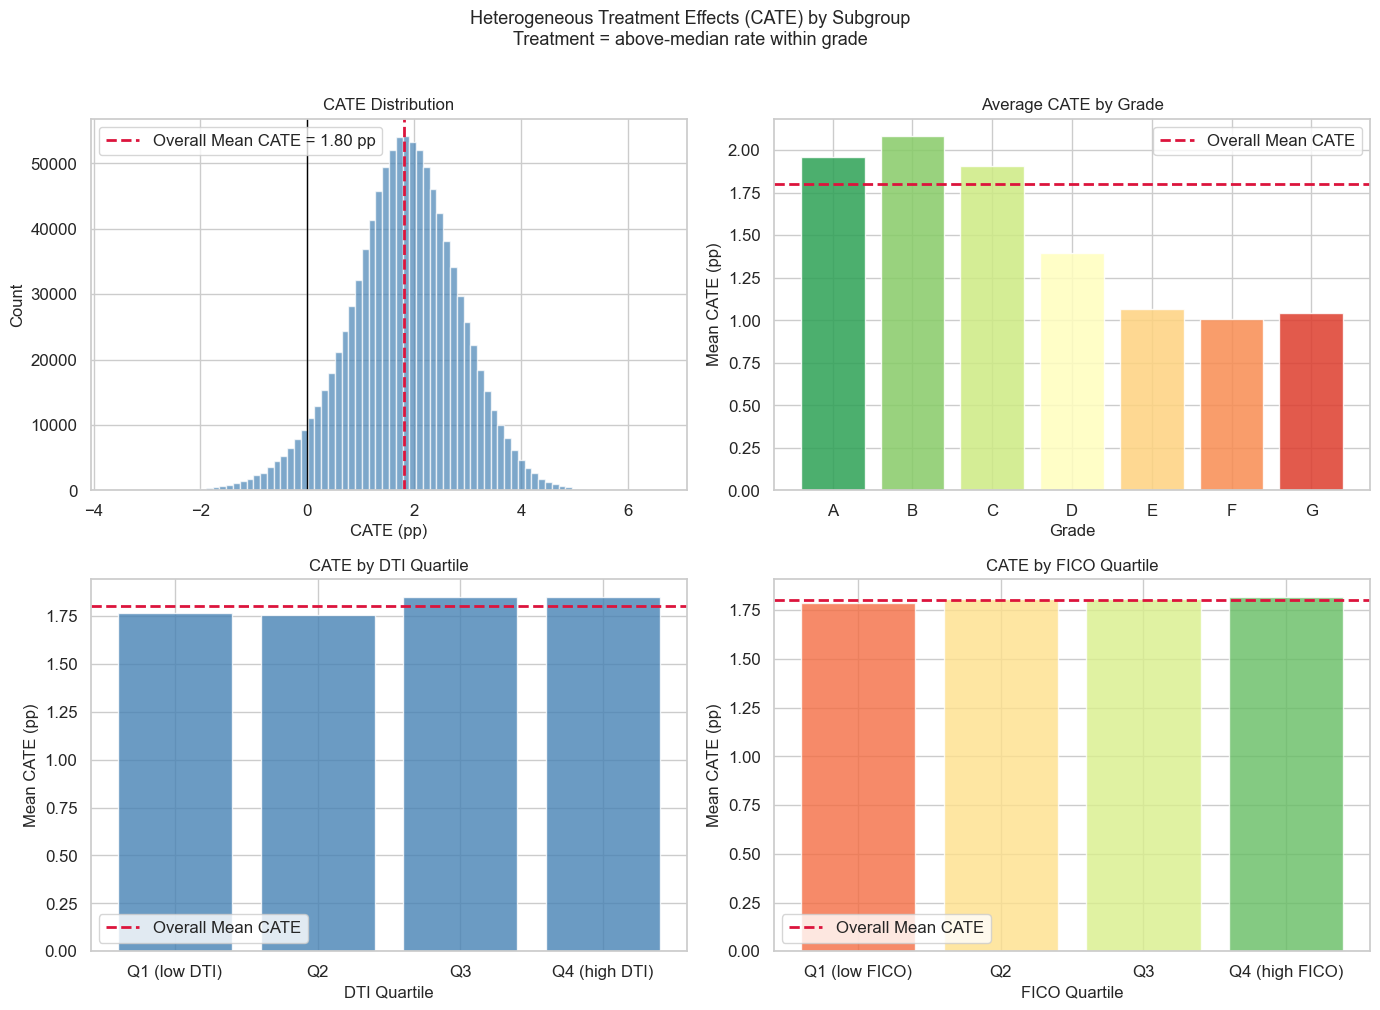

Mean CATE by term:
               mean   count
term_months                
36           0.0206  777875
60           0.0100  248042

Mean CATE by high rate:
             mean   count
high_rate                
0.0        0.0188  544376
1.0        0.0172  481541


In [126]:
GRADE_ORDER = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
sub_grades = [f"{g}{i}" for g in GRADE_ORDER for i in range(1, 6)]
decode_map = {i: val for i, val in enumerate(sub_grades)}

mdf['sub_grade'] = mdf['subgrade_num'].map(decode_map)
mdf['grade'] = mdf['sub_grade'].str[0]

mdf['term_months'] = np.where(mdf['term_months_encoded']==0, 36, 60)

cate_df = mdf[['default','high_rate','grade','sub_grade',
               'fico_mid','dti','term_months']].copy()
cate_df['cate'] = cate

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CATE distribution
ax = axes[0, 0]
ax.hist(cate*100, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(ate_cf*100, color='crimson', linewidth=2, linestyle='--',
           label=f'Overall Mean CATE = {ate_cf*100:.2f} pp')
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('CATE (pp)', fontsize=12); ax.set_ylabel('Count', fontsize=12)
ax.set_title('CATE Distribution', fontsize=12); ax.legend()

# CATE by grade
ax = axes[0, 1]
cate_g = cate_df.groupby('grade')['cate'].mean().loc[
    [g for g in GRADE_ORDER if g in cate_df['grade'].unique()]
]
ax.bar(cate_g.index, cate_g.values*100,
       color=GRADE_PALETTE[:len(cate_g)], alpha=0.85, edgecolor='white')
ax.axhline(ate_cf*100, color='crimson', linewidth=2, linestyle='--', label='Overall Mean CATE')
ax.set_xlabel('Grade', fontsize=12); ax.set_ylabel('Mean CATE (pp)', fontsize=12)
ax.set_title('Average CATE by Grade', fontsize=12); ax.legend()

# CATE by DTI quartile
ax = axes[1, 0]
cate_df['dti_q'] = pd.qcut(cate_df['dti'], q=4,
                            labels=['Q1 (low DTI)','Q2','Q3','Q4 (high DTI)'])
cate_dti = cate_df.groupby('dti_q', observed=True)['cate'].mean()*100
ax.bar(cate_dti.index, cate_dti.values, color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(ate_cf*100, color='crimson', linewidth=2, linestyle='--', label='Overall Mean CATE')
ax.set_xlabel('DTI Quartile', fontsize=12); ax.set_ylabel('Mean CATE (pp)', fontsize=12)
ax.set_title('CATE by DTI Quartile', fontsize=12); ax.legend()

# CATE by FICO quartile
ax = axes[1, 1]
cate_df['fico_q'] = pd.qcut(cate_df['fico_mid'], q=4,
                              labels=['Q1 (low FICO)','Q2','Q3','Q4 (high FICO)'])
cate_fico = cate_df.groupby('fico_q', observed=True)['cate'].mean()*100
ax.bar(cate_fico.index, cate_fico.values,
       color=sns.color_palette('RdYlGn', n_colors=4), alpha=0.8, edgecolor='white')
ax.axhline(ate_cf*100, color='crimson', linewidth=2, linestyle='--', label='Overall Mean CATE')
ax.set_xlabel('FICO Quartile', fontsize=12); ax.set_ylabel('Mean CATE (pp)', fontsize=12)
ax.set_title('CATE by FICO Quartile', fontsize=12); ax.legend()

plt.suptitle('Heterogeneous Treatment Effects (CATE) by Subgroup\n'
             'Treatment = above-median rate within grade', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig20_cate_subgroups.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean CATE by term:')
print(cate_df.groupby('term_months')['cate'].agg(['mean','count']).round(4))

print('\nMean CATE by high rate:')
print(cate_df.groupby('high_rate')['cate'].agg(['mean', 'count']).round(4))

Since treatment is defined as receiving an interest rate above the within-grade median, the estimated CATE captures the effect of a relatively higher interest rate among borrowers with similar grade-level risk. The larger treatment effects in lower-risk grades (A–C) suggest that additional interest burden may more directly increase default risk for otherwise safer borrowers. In contrast, the smaller effects in higher-risk grades (D–G) may indicate that, among already risky borrowers, the marginal impact of a higher rate is less pronounced because default is driven by a broader set of underlying risk factors. Meanwhile, the relatively small variation across DTI and FICO quantiles suggests limited additional heterogeneity along these dimensions.

---
## Method 5 — Sub-Grade Boundary Analysis

In [128]:
boundary_rows = []
for i in range(len(GRADE_ORDER) - 1):
    g_lo, g_hi = GRADE_ORDER[i], GRADE_ORDER[i+1]
    lo = mdf[mdf['sub_grade'] == f'{g_lo}5']
    hi = mdf[mdf['sub_grade'] == f'{g_hi}1']
    if len(lo) < 100 or len(hi) < 100: continue

    rate_diff    = hi['int_rate'].mean() - lo['int_rate'].mean()
    default_diff = hi['default'].mean()  - lo['default'].mean()
    wald = default_diff / rate_diff if abs(rate_diff) > 0.01 else np.nan
    t_stat, p = stats.ttest_ind(hi['default'], lo['default'])

    boundary_rows.append({
        'boundary': f'{g_lo}5 | {g_hi}1',
        'n_lo': len(lo),
        'n_hi': len(hi),
        'rate_jump_pp': rate_diff,
        'default_lo': lo['default'].mean(),
        'default_hi': hi['default'].mean(),
        'default_diff_pp': default_diff,
        'wald_est': wald,
        'fico_diff': hi['fico_mid'].mean() - lo['fico_mid'].mean(),
        'p_value': p
    })

bnd_df = pd.DataFrame(boundary_rows)
print('=== SUB-GRADE BOUNDARY ANALYSIS ===')
print(bnd_df.round(4).to_string(index=False))

=== SUB-GRADE BOUNDARY ANALYSIS ===
boundary  n_lo  n_hi  rate_jump_pp  default_lo  default_hi  default_diff_pp  wald_est  fico_diff  p_value
 A5 | B1 49066 54060        0.5712      0.0817      0.1018           0.0201    0.0353    -0.2919   0.0000
 B5 | C1 61310 64688        0.7317      0.1658      0.1874           0.0216    0.0295    -0.0077   0.0000
 C5 | D1 50111 40667        0.8323      0.2564      0.2769           0.0205    0.0247    -0.0589   0.0000
 D5 | E1 22986 19664        0.4990      0.3391      0.3687           0.0296    0.0594    -0.0170   0.0000
 E5 | F1 10265  7828        0.8895      0.4282      0.4287           0.0006    0.0006    -0.0197   0.9395
 F5 | G1  3002  2071        0.5148      0.5040      0.4949          -0.0091   -0.0176    -0.0092   0.5256


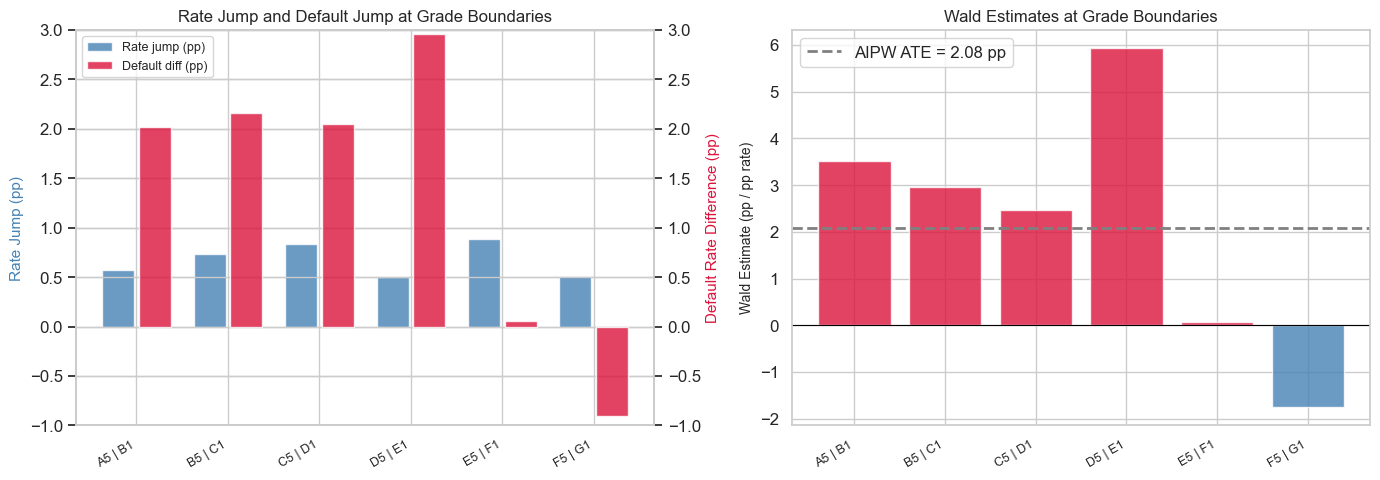

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rate jump and default jump
ax = axes[0]
x  = np.arange(len(bnd_df))
ax.bar(x - 0.2, bnd_df['rate_jump_pp'], width=0.35,
       color='steelblue', alpha=0.8, label='Rate jump (pp)')
ax2 = ax.twinx()
ax2.bar(x + 0.2, bnd_df['default_diff_pp']*100, width=0.35,
        color='crimson', alpha=0.8, label='Default diff (pp)')
ax.set_xticks(x)
ax.set_xticklabels(bnd_df['boundary'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(-1, 3)
ax2.set_ylim(-1, 3)
ax.set_ylabel('Rate Jump (pp)', color='steelblue', fontsize=11)
ax2.set_ylabel('Default Rate Difference (pp)', color='crimson', fontsize=11)
ax.set_title('Rate Jump and Default Jump at Grade Boundaries', fontsize=12)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=9)

# Wald estimates
ax = axes[1]
valid  = bnd_df.dropna(subset=['wald_est'])
colors = ['crimson' if v > 0 else 'steelblue' for v in valid['wald_est']]
ax.bar(valid['boundary'], valid['wald_est']*100, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(ate_aipw*100, color='grey', linewidth=2, linestyle='--',
           label=f'AIPW ATE = {ate_aipw*100:.2f} pp')
ax.set_ylabel('Wald Estimate (pp / pp rate)', fontsize=10)
ax.set_title('Wald Estimates at Grade Boundaries', fontsize=12)
ax.set_xticklabels(valid['boundary'], rotation=30, ha='right', fontsize=9)
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/fig21_boundary_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

A boundary analysis around grade cutoffs shows that discrete increases in interest rates are associated with significant increases in default rates for lower and mid-risk grades (A–D). However, this effect diminishes and becomes statistically insignificant for higher-risk grades (E–G). This pattern is consistent with the CATE estimates from the causal forest, suggesting that the marginal impact of higher interest rates is concentrated among relatively safer borrowers and weakens for already high-risk segments.

---
## Results Summary

In [132]:
summary = pd.DataFrame([
    {'Method': 'Naive difference', 'Treatment': 'high_rate', 'ATE (pp)': ate_naive*100, 
     '95% CI': 'N/A'},
    {'Method': 'IPW-ATE', 'Treatment': 'high_rate', 'ATE (pp)': ate_ipw*100, 
     '95% CI': f'[{ci_lo_ipw*100:.3f}, {ci_hi_ipw*100:.3f}]'},
    {'Method': 'AIPW (doubly robust)-ATE', 'Treatment': 'high_rate', 'ATE (pp)': ate_aipw*100,
     '95% CI': f'[{ci_lo_aipw*100:.3f}, {ci_hi_aipw*100:.3f}]'},
    {'Method': 'DML (per 1 pp rate)', 'Treatment': 'int_rate', 'ATE (pp)': theta_dml*100,
     '95% CI': f'[{(theta_dml-1.96*se_dml)*100:.4f}, {(theta_dml+1.96*se_dml)*100:.4f}]'},
    {'Method': 'Causal Forest mean CATE', 'Treatment': 'high_rate', 'ATE (pp)': ate_cf*100, 
     '95% CI': '—'},
])
summary['ATE (pp)'] = summary['ATE (pp)'].round(4)

print('=' * 65)
print('CAUSAL INFERENCE RESULTS')
print('Treatment: high_rate (above-median rate within grade)')
print('Outcome  : default (binary)')
print('=' * 65)
print(summary.to_string(index=False))
print()

CAUSAL INFERENCE RESULTS
Treatment: high_rate (above-median rate within grade)
Outcome  : default (binary)
                  Method Treatment  ATE (pp)           95% CI
        Naive difference high_rate    1.7073              N/A
                 IPW-ATE high_rate    2.4473   [2.281, 2.615]
AIPW (doubly robust)-ATE high_rate    2.0800   [1.922, 2.238]
     DML (per 1 pp rate)  int_rate    1.1532 [1.0830, 1.2235]
 Causal Forest mean CATE high_rate    1.8027                —



**Key Takeaways:**

1. All methods find a positive, significant effect of high rate on default.
2. Differences between naive and causal estimates highlight the importance of adjusting for confounding in interest rate assignment. The naive estimate reflects both interest rate effects and underlying borrower risk, and therefore does not represent a causal effect. Because treatment is not randomly assigned, the selection bias can go in either direction. Causal methods correct for this by adjusting for observable differences across borrowers.
4. Treatment effects exhibit clear heterogeneity across credit grades, with stronger effects in lower-risk segments and weaker effects in higher-risk segments.
5. In contrast, heterogeneity across DTI and FICO is limited, indicating that grade captures most of the relevant variation in treatment effects.

*Interest rates may help screen borrowers at the selection stage, but conditional on loan origination, higher interest rates increase the probability of default.*